In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from coleta import  order_items, order_payments, orders, products

In [3]:
merge_orders = order_payments.merge(order_items, on="order_id").merge(orders, on="order_id").merge(products, on="product_id")

### Filtrando ordens que mais fazem sentido ao analisar vendas realizadas e entregues

In [4]:
merge_orders = merge_orders[merge_orders['order_status'] == 'delivered'].dropna(axis=0, how="any")

In [5]:
# Verificando se há valores ausentes

merge_orders.isna().sum()

order_id                         0
payment_sequential               0
payment_type                     0
payment_installments             0
payment_value                    0
order_item_id                    0
product_id                       0
seller_id                        0
shipping_limit_date              0
price                            0
freight_value                    0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
product_category_name            0
product_name_lenght              0
product_description_lenght       0
product_photos_qty               0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
dtype: int64

- Primeira pergunta de negócio: Quais categorias de produtos possuem maior volume de vendas?

In [6]:
categoria_maior_volume_vendas = merge_orders.groupby('product_category_name').agg({"product_category_name":"count"})
categoria_maior_volume_vendas.rename(columns={'product_category_name':'volume_vendas'}, inplace=True)
categoria_maior_volume_vendas = categoria_maior_volume_vendas.sort_values(by='volume_vendas', ascending=False).reset_index()

In [7]:
categoria_maior_volume_vendas.head(5)

,product_category_name,volume_vendas
0,cama_mesa_banho,11649
1,beleza_saude,9759
2,esporte_lazer,8730
3,moveis_decoracao,8553
4,informatica_acessorios,7897


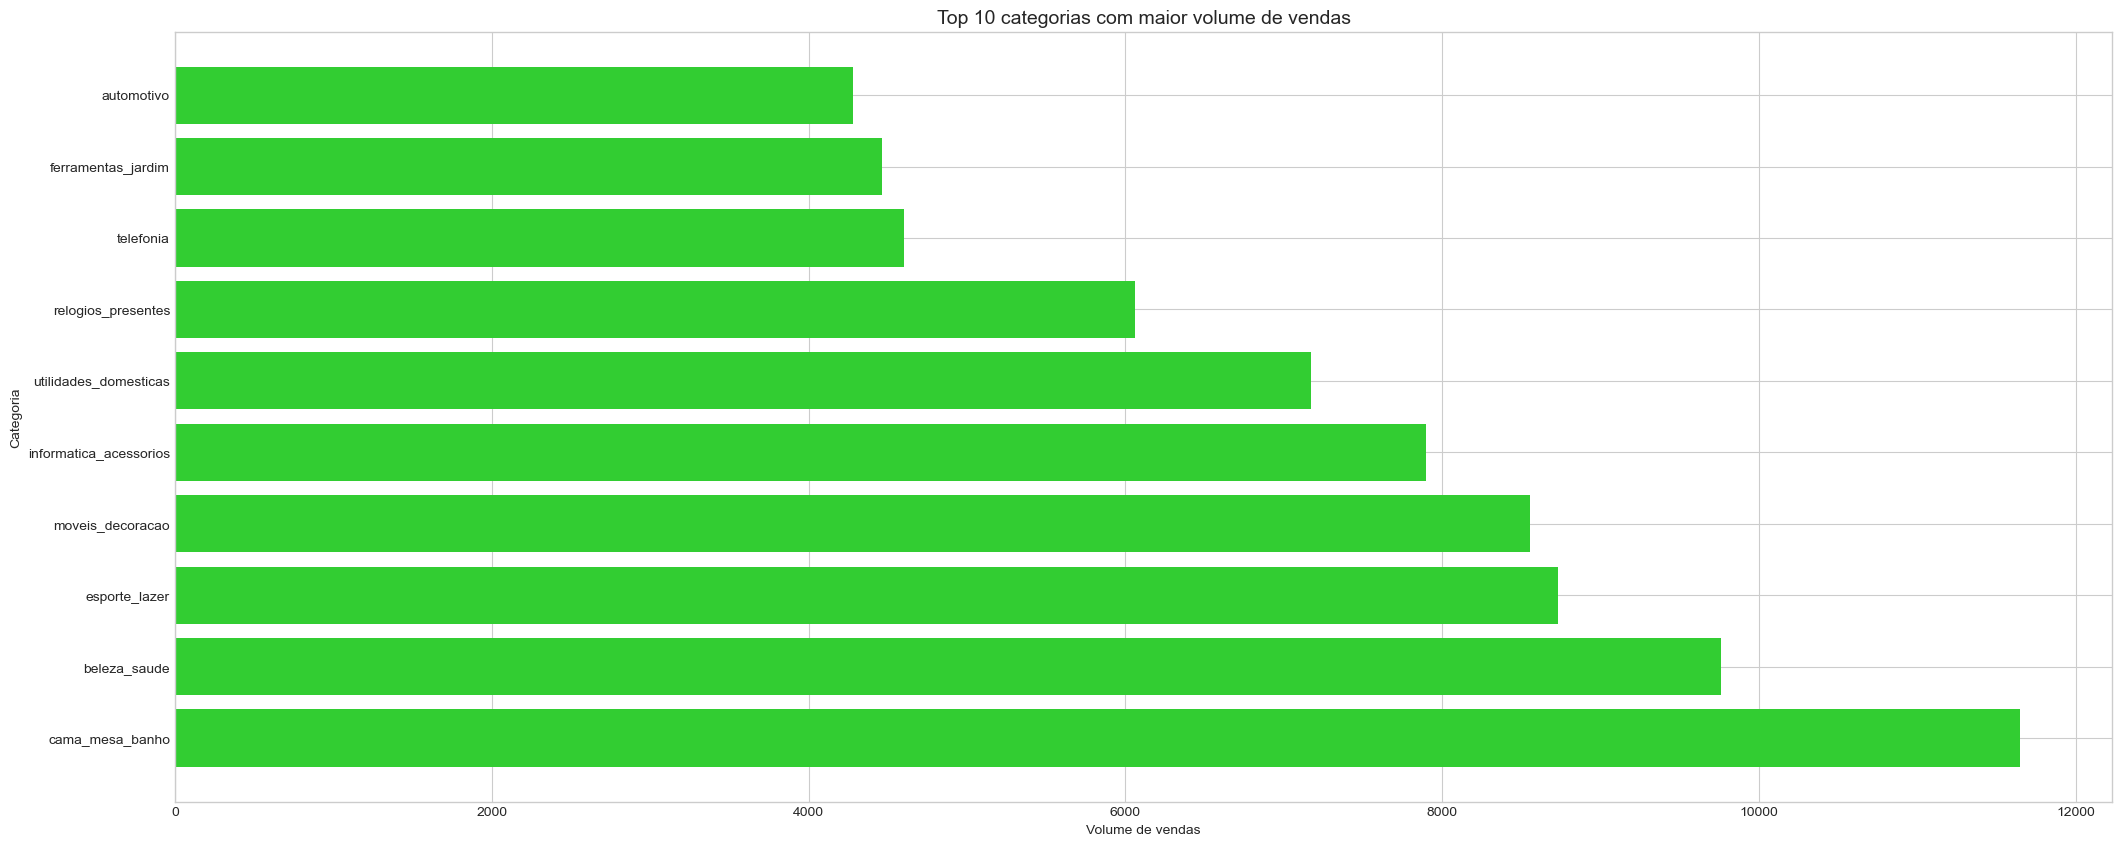

In [8]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(25, 10))
plt.barh(categoria_maior_volume_vendas['product_category_name'].head(10), categoria_maior_volume_vendas['volume_vendas'].head(10), color='limegreen')
plt.title('Top 10 categorias com maior volume de vendas', fontsize=14)
plt.xlabel('Volume de vendas')
plt.ylabel('Categoria')
plt.show()

- Segunda pergunta de negócio: Quais categorias geram o maior faturamento?

In [9]:
categoria_maior_faturamento = merge_orders.groupby('product_category_name').agg({'price':'sum'}).sort_values(by='price', ascending=False).reset_index()

In [10]:
categoria_maior_faturamento.head(10)

,product_category_name,price
0,beleza_saude,1271333.29
1,relogios_presentes,1213162.80
2,cama_mesa_banho,1077834.14
3,esporte_lazer,990396.24
4,informatica_acessorios,918837.87
5,moveis_decoracao,745748.80
6,utilidades_domesticas,648187.74
7,cool_stuff,634163.78
8,automotivo,602881.75
9,ferramentas_jardim,492255.08


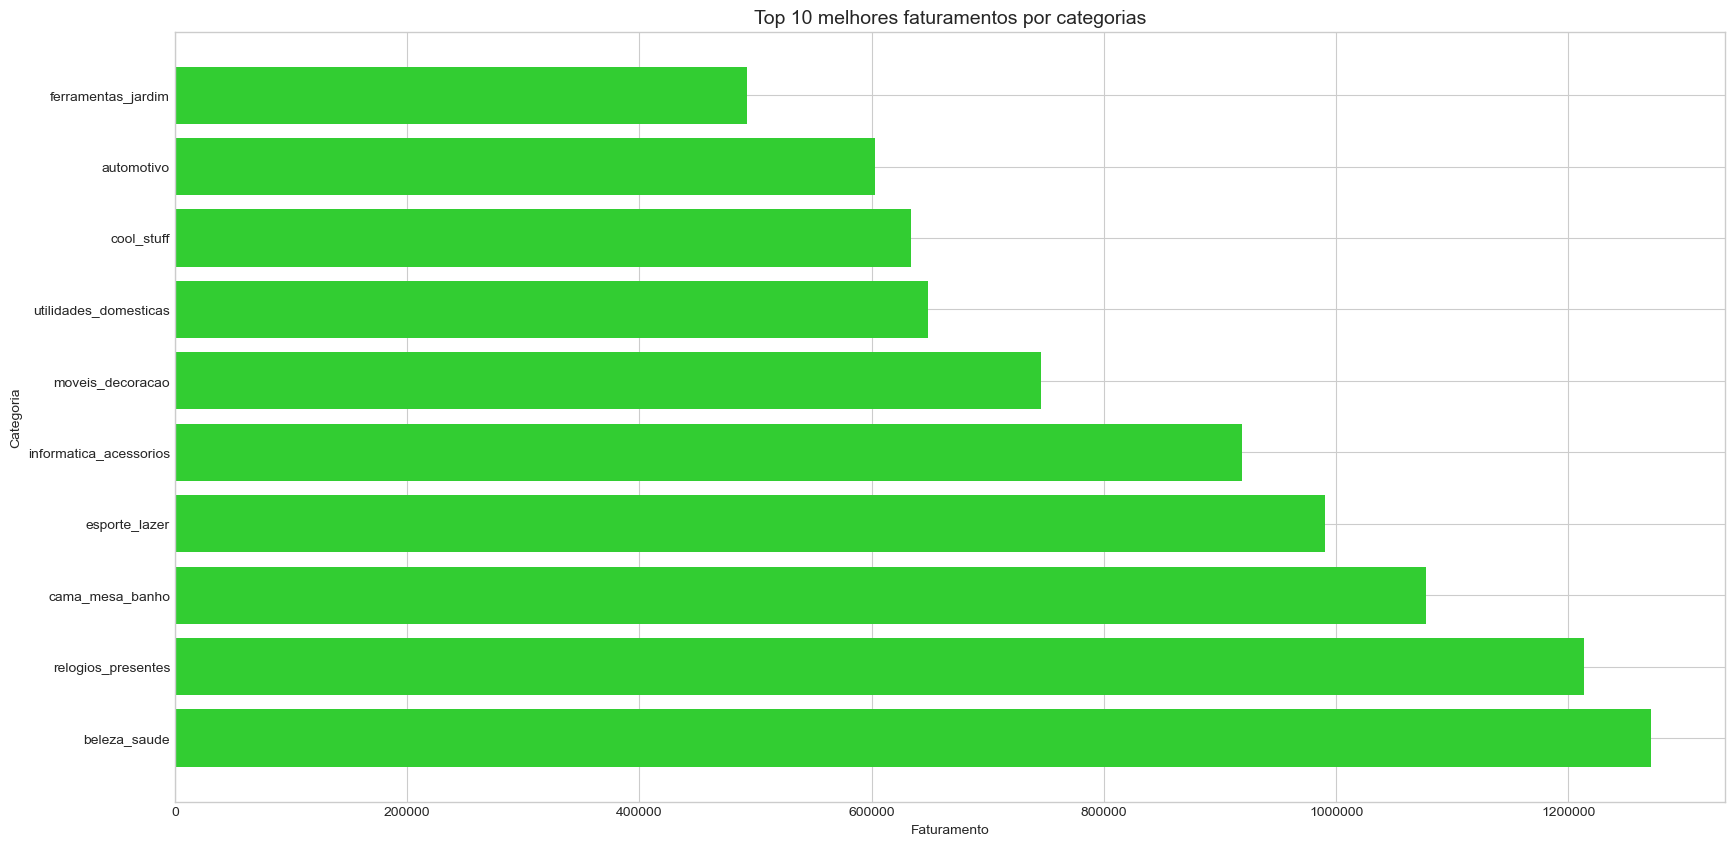

In [11]:
plt.figure(figsize=(20, 10))
plt.barh(categoria_maior_faturamento['product_category_name'].head(10), categoria_maior_faturamento['price'].head(10), color='limegreen')
plt.title('Top 10 melhores faturamentos por categorias', fontsize=14)
plt.xlabel('Faturamento')
plt.ylabel('Categoria')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

- Terceira pergunta de negócio: As categorias que vendem mais unidades também são as que geram maior faturamento?

        Sim, analisando o volume de vendas e o faturamento das categorias, pode-se afirmar que as categorias que mais vendem também são as categorias que mais faturam

- Quarta pergunta de negócio: Quais categorias possuem maior preço médio?

In [12]:
preco_medio_categorias = merge_orders.groupby('product_category_name').agg({'price':'mean'}).sort_values(by='price', ascending=False).reset_index()

In [13]:
preco_medio_categorias.head()

,product_category_name,price
0,pcs,1104.317685
1,portateis_casa_forno_e_cafe,641.194133
2,eletrodomesticos_2,451.729962
3,agro_industria_e_comercio,332.835691
4,instrumentos_musicais,296.108561


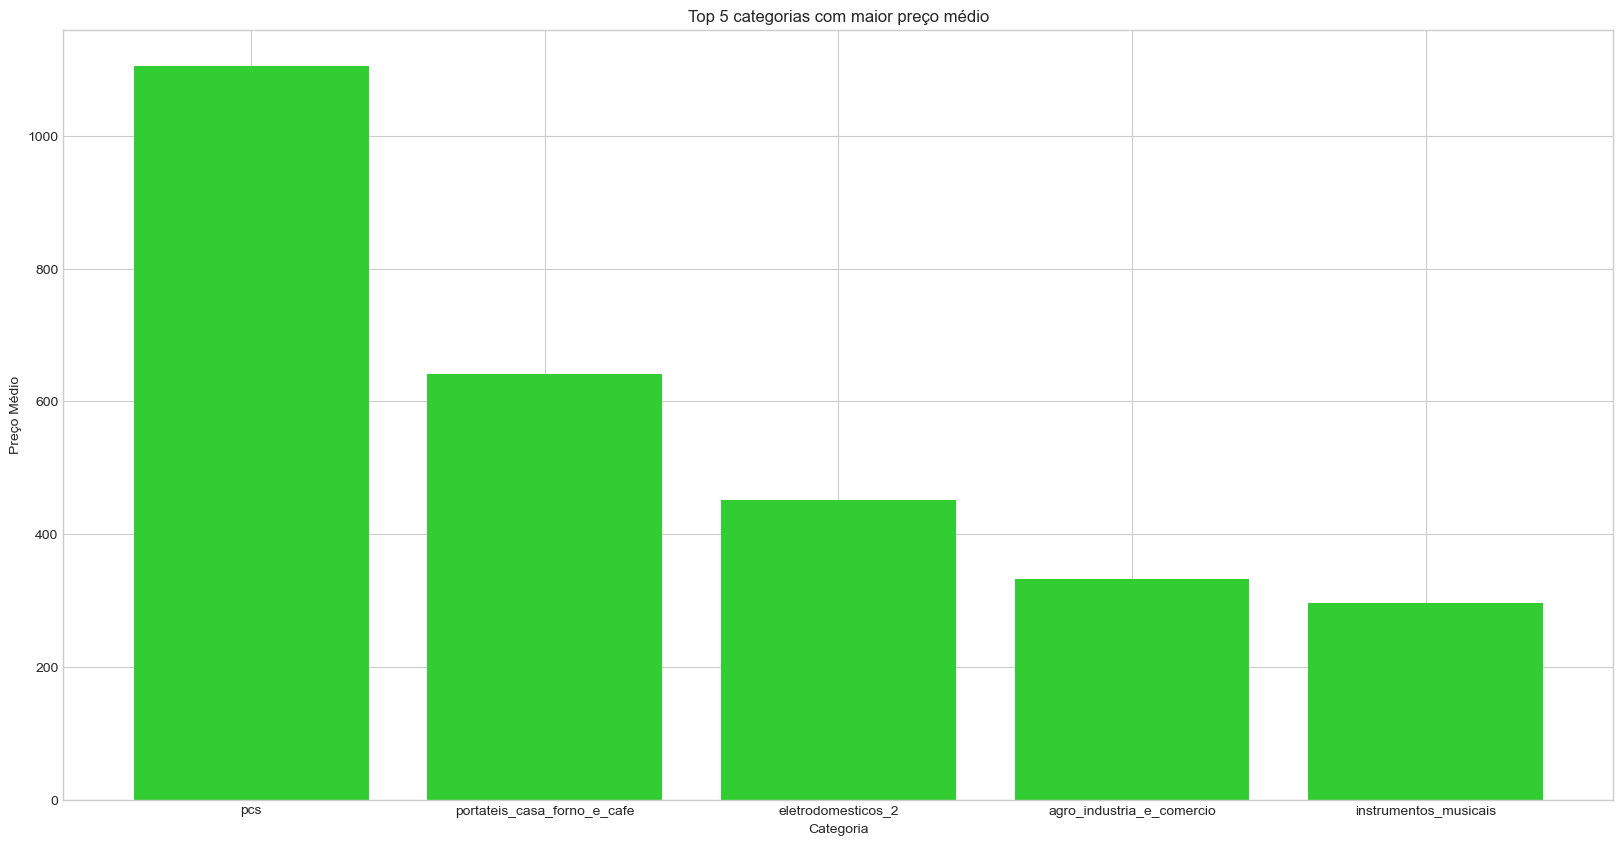

In [14]:
plt.figure(figsize=(20, 10))
plt.bar(preco_medio_categorias['product_category_name'].head(), preco_medio_categorias['price'].head(), color='limegreen')
plt.title('Top 5 categorias com maior preço médio')
plt.xlabel('Categoria')
plt.ylabel('Preço Médio')
plt.show()

- Quinta pergunta de negócio: Existe concentração significativa do faturamento em poucas categorias ou produtos?

In [15]:
faturamento_total = merge_orders['price'].sum()

In [16]:
distribuicao_faturamento_categorias = merge_orders.groupby('product_category_name').agg(distribuicao=('price', lambda x: x.sum() / faturamento_total * 100)).sort_values(by='distribuicao', ascending=False).reset_index()

In [17]:
distribuicao_faturamento_categorias.head(10)

,product_category_name,distribuicao
0,beleza_saude,9.329501
1,relogios_presentes,8.902625
2,cama_mesa_banho,7.909534
3,esporte_lazer,7.267884
4,informatica_acessorios,6.742763
5,moveis_decoracao,5.472573
6,utilidades_domesticas,4.756635
7,cool_stuff,4.653722
8,automotivo,4.424163
9,ferramentas_jardim,3.612345


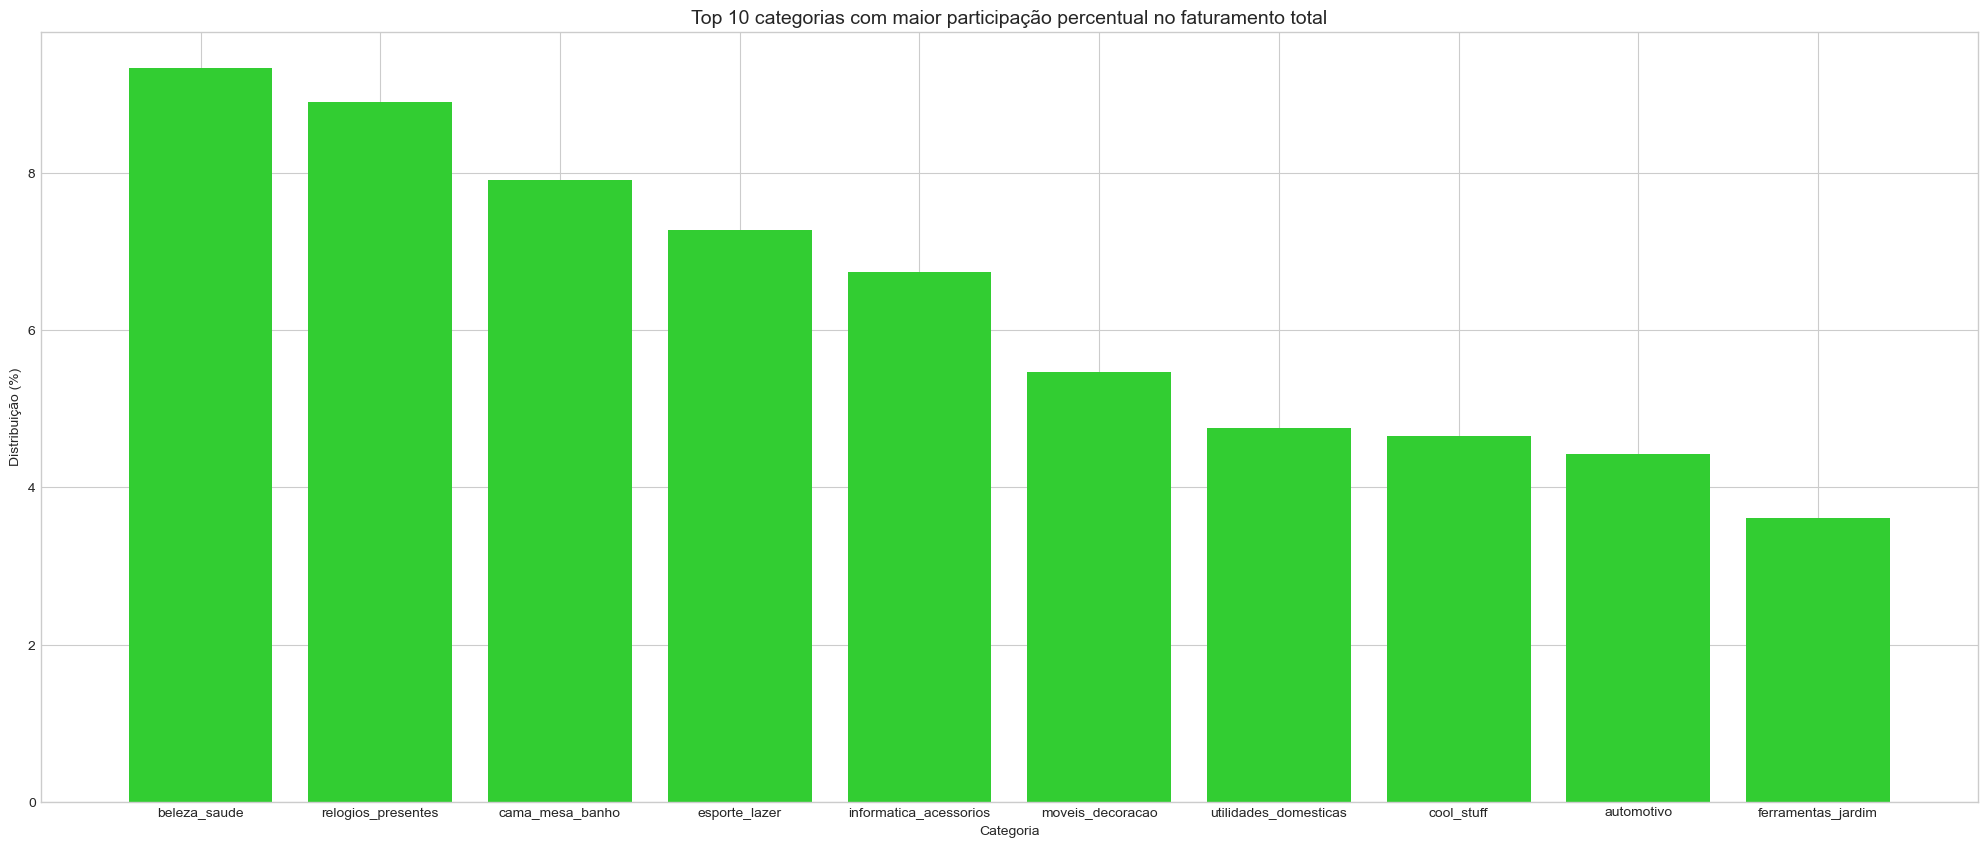

In [18]:
plt.figure(figsize=(25, 10))
plt.bar(distribuicao_faturamento_categorias['product_category_name'].head(10), distribuicao_faturamento_categorias['distribuicao'].head(10), color='limegreen')
plt.title('Top 10 categorias com maior participação percentual no faturamento total', fontsize=14)
plt.xlabel('Categoria')
plt.ylabel('Distribuição (%)')
plt.show()

In [19]:
soma_participacao_top_10_categorias = distribuicao_faturamento_categorias['distribuicao'].head(10).sum()

In [20]:
print(soma_participacao_top_10_categorias)

63.071742285506566


    Sim, existe uma concentração significativa de faturamento em certas categorias. Por exemplo, as top 10 categorias que mais faturam concentram cerca de 63% de todo o faturamento da empresa. Sendo que existem um total de 73 categorias.